# Example climb: Feature interactions with weak individual correlations

## 1. Notebook setup

### 1.1. Imports

In [1]:
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

sys.path.append('..')

from hill_climber import HillClimber

np.random.seed(315)

### 1.2. Input distributions

In [2]:
# Create input distributions: 3 features (x1, x2, x3) and 1 label (y)
n = 10000

data = pd.DataFrame({
    'x1': np.random.uniform(-1, 1, n),
    'x2': np.random.uniform(-1, 1, n),
    'x3': np.random.uniform(-1, 1, n),
    'y': np.random.uniform(-1, 1, n)
})

print('Initial data statistics:')
print(data.describe())
print('\nInitial correlations with label:')

for col in ['x1', 'x2', 'x3']:
    corr, _ = pearsonr(data[col], data['y'])
    print(f"{col}-y: {corr:.4f}")

# Check initial linear regression R²
X = data[['x1', 'x2', 'x3']].values
y = data['y'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

Initial data statistics:
                 x1            x2            x3             y
count  10000.000000  10000.000000  10000.000000  10000.000000
mean       0.005054     -0.002935      0.007304     -0.002762
std        0.576990      0.583597      0.577726      0.578998
min       -0.999388     -0.999889     -0.999624     -0.999996
25%       -0.500268     -0.516427     -0.491271     -0.498037
50%        0.011873     -0.001932      0.007384     -0.011698
75%        0.510160      0.506083      0.514164      0.502203
max        0.999923      0.999701      0.999626      0.999863

Initial correlations with label:
x1-y: -0.0011
x2-y: 0.0163
x3-y: 0.0006


## 2. Optimize for weak individual correlations but strong collective prediction

### 2.1. Objective function

In [3]:
def objective_feature_interactions(x1, x2, x3, y):
    '''Maximize multiple linear regression R² while minimizing individual feature-label correlations.
    
    This creates datasets where features interact to predict the label, but individual features
    alone are poor predictors. This demonstrates the importance of feature interactions.
    
    Args:
        x1, x2, x3: Feature variables (array-like)
        y: Label variable (array-like)
    
    Returns:
        Tuple of (metrics_dict, objective_value)
    '''
    
    # Convert to numpy arrays
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)
    x3 = np.asarray(x3)
    y = np.asarray(y)
    
    # Calculate individual Pearson correlations with label
    x1_y_r, _ = pearsonr(x1, y)
    x2_y_r, _ = pearsonr(x2, y)
    x3_y_r, _ = pearsonr(x3, y)
    
    # Average R² of individual features (want this LOW)
    avg_individual_r = np.mean([x1_y_r**2, x2_y_r**2, x3_y_r**2])

    # Calculate pairwise feature correlations
    x1_x2_r, _ = pearsonr(x1, x2)
    x1_x3_r, _ = pearsonr(x1, x3)
    x2_x3_r, _ = pearsonr(x2, x3)

    # Average R² of feature-feature correlations (want this LOW)
    avg_feature_r = np.mean([x1_x2_r**2, x1_x3_r**2, x2_x3_r**2])

    # Calculate regression model R² (want this HIGH)

    # Draw train-test split
    random_indices = random.sample(range(len(y)), int(0.7*len(y)))
    train_mask = np.zeros(len(y), dtype=bool)
    train_mask[random_indices] = True
    test_mask = ~train_mask

    X_train = np.column_stack([x1[train_mask], x2[train_mask], x3[train_mask]])
    y_train = y[train_mask]

    X_test = np.column_stack([x1[test_mask], x2[test_mask], x3[test_mask]])
    y_test = y[test_mask]

    # Train and score the model
    model = DecisionTreeRegressor(max_depth=8).fit(X_train, y_train)
    mlr_r2 = r2_score(y_test, model.predict(X_test))
    
    # Calculate objective
    objective = mlr_r2 - (avg_individual_r * 0.05) - (avg_feature_r * 0.05)
    
    # Compile metrics
    metrics = {
        'Model R²': float(mlr_r2),
        'Avg individual R²': float(avg_individual_r),
        'Avg feature R²': float(avg_feature_r),
    }
    
    return metrics, float(objective)

### 2.2. Hill climbing run

In [ ]:
# Create HillClimber instance with replica exchange
climber = HillClimber(
    data=data,
    objective_func=objective_feature_interactions,
    initial_step_spread=1.0,
    final_step_spread=0.1,
    T_min=1e-3,
    T_max=200,
    cooling_rate=1e-3,
    exchange_interval=50,
    max_time=240,
    n_replicas=20,
    db_path='../data/feature_interactions.db'
)

# Run optimization
best_data_df = climber.climb()

HillClimber Configuration

Data shape:           (10000, 4)
Optimization mode:    maximize
Max runtime:          90 minutes

Temperature settings:
  T_min:              0.001
  T_max:              200
  Cooling rate:       0.002
  Temperature scheme: geometric

Replica exchange:
  Number of replicas: 20
  Exchange interval:  50 steps
  Exchange strategy:  even_odd
  Worker processes:   20

Perturbation settings:
  Initial step spread: 1.0 (fraction of range)
  Final step spread:   0.1 (fraction at end of run)
  Perturb fraction:    0.001

Database settings:
  Enabled:            True
  Path:               ../data/feature_interactions.db
  Step interval:      5



### 2.3. Results

In [5]:
train_df, test_df = train_test_split(best_data_df, test_size=100, random_state=315)
train_df.head()

,x1,x2,x3,y
4194,0.752747,-0.593843,0.893474,0.947925
96,0.381961,-0.758643,0.141513,0.067557
1842,-0.532065,0.834169,0.642412,0.498242
2567,0.797253,-0.853385,0.969691,0.754582
3751,-0.378293,0.509684,0.040132,-0.397071


#### 2.3.1. Gradient boosting regression

In [6]:
model = GradientBoostingRegressor(n_estimators=50, max_depth=10)
model.fit(train_df[['x1', 'x2', 'x3']].values, train_df['y'].values)

y_pred = model.predict(test_df[['x1', 'x2', 'x3']].values)
residuals = test_df['y'].values - y_pred
standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
root_standardized_residuals = np.sqrt(np.abs(standardized_residuals))
r2 = r2_score(test_df['y'].values, y_pred)
print(f'Model R²: {r2:.2f}')

Model R²: -0.02


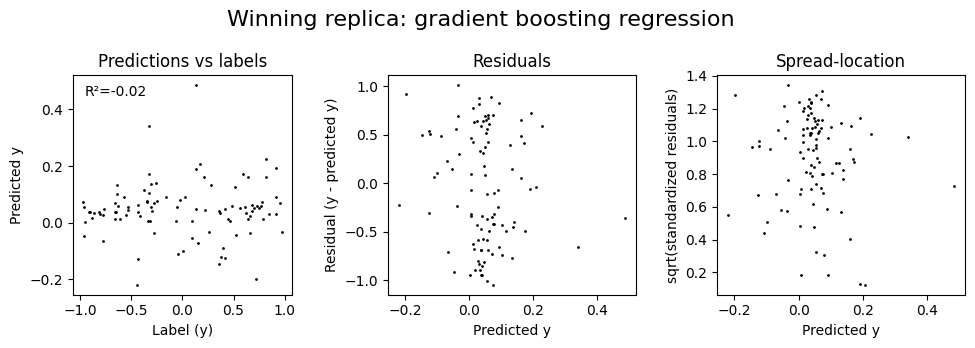

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle('Winning replica: gradient boosting regression', fontsize=16)

axs[0].set_title('Predictions vs labels')
stats=f'R²={r2:.2f}'
axs[0].annotate(xy=(-0.95, np.max(y_pred)), text=stats, ha='left', va='top', bbox=dict(boxstyle='square', fc='white', ec='white'))
axs[0].scatter(test_df['y'].values, y_pred, s=1, c='black')
axs[0].set_xlabel('Label (y)')
axs[0].set_ylabel('Predicted y')
axs[0].set_box_aspect(1)

axs[1].set_title('Residuals')
axs[1].scatter(y_pred, residuals, s=1, c='black')
axs[1].set_xlabel('Predicted y')
axs[1].set_ylabel('Residual (y - predicted y)')
axs[0].set_box_aspect(1)

axs[2].set_title('Spread-location')
axs[2].scatter(y_pred, root_standardized_residuals, s=1, c='black')
axs[2].set_xlabel('Predicted y')
axs[2].set_ylabel('sqrt(standardized residuals)')
axs[0].set_box_aspect(1)

plt.tight_layout()
plt.show()

#### 2.3.2. Feature-label correlations

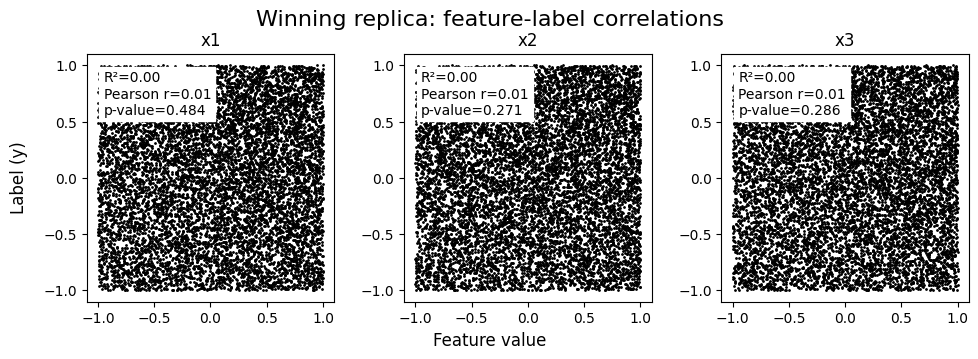

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle('Winning replica: feature-label correlations', fontsize=16)
fig.supxlabel('Feature value')
fig.supylabel('Label (y)')

for i, feature in enumerate(['x1', 'x2', 'x3']):

    slope, intercept, r_value, p_value, std_err = linregress(best_data_df[feature], best_data_df['y'])
    stats=f'R²={r_value**2:.2f}\nPearson r={r_value:.2f}\np-value={p_value:.3f}'

    axs[i].set_title(feature)
    axs[i].annotate(xy=(-0.95, 0.95), text=stats, ha='left', va='top', bbox=dict(boxstyle='square', fc='white', ec='white'))
    axs[i].scatter(best_data_df[feature], best_data_df['y'], s=1, c='black')
    axs[i].set_aspect('equal')

plt.tight_layout()
plt.show()

#### 2.3.3. Feature-feature correlations

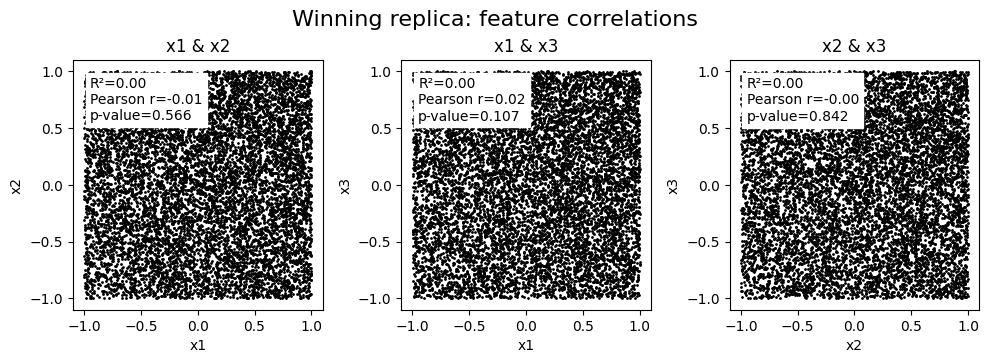

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle('Winning replica: feature correlations', fontsize=16)

for i, features in enumerate([['x1', 'x2'],['x1', 'x3'], ['x2', 'x3']]):

    slope, intercept, r_value, p_value, std_err = linregress(best_data_df[features[0]], best_data_df[features[1]])
    stats=f'R²={r_value**2:.2f}\nPearson r={r_value:.2f}\np-value={p_value:.3f}'

    axs[i].set_title(f'{features[0]} & {features[1]}')
    axs[i].annotate(xy=(-0.95, 0.95), text=stats, ha='left', va='top', bbox=dict(boxstyle='square', fc='white', ec='white'))
    axs[i].scatter(best_data_df[features[0]], best_data_df[features[1]], s=1, c='black')
    axs[i].set_xlabel(features[0])
    axs[i].set_ylabel(features[1])
    axs[i].set_aspect('equal')

plt.tight_layout()
plt.show()

#### 2.3.4. Replicate regression models

In [10]:
replicas = climber.get_replicas()
print(f'Have {len(replicas)} replicas')

Have 20 replicas


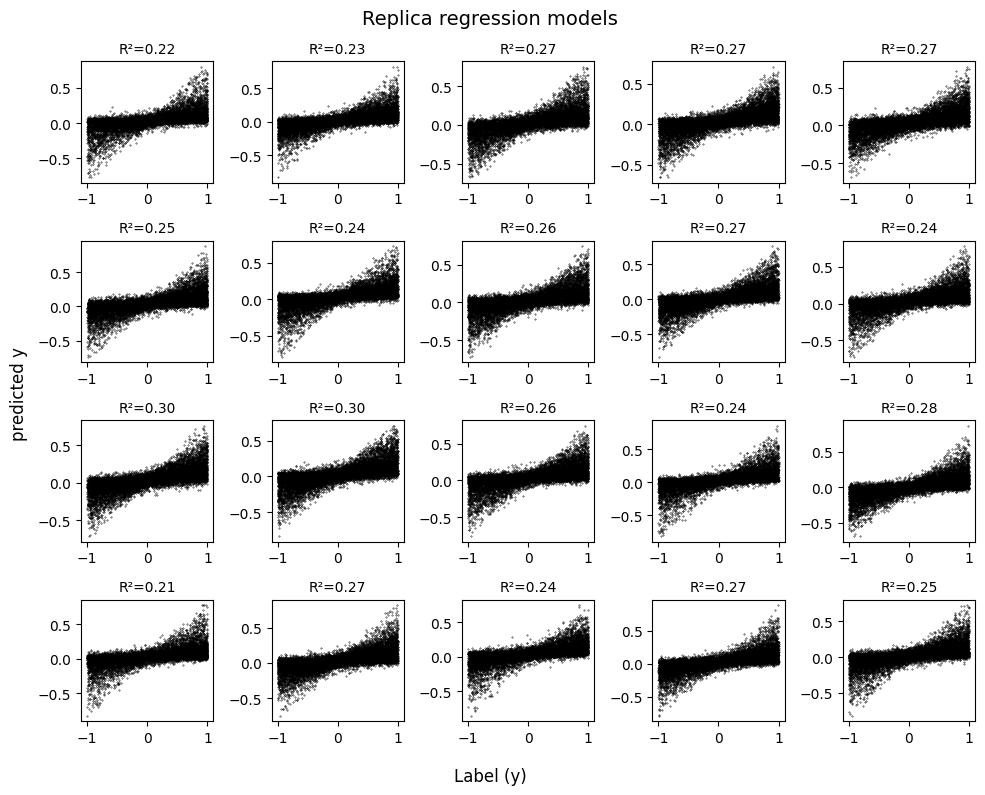

In [11]:
replicates = climber.get_replicas()
ncols = 5
nrows = len(replicates) // ncols

if len(replicates) % ncols != 0:
    nrows+=1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2, nrows*2))
axs = axs.flatten()

fig.suptitle('Replica regression models', fontsize=14)
fig.supxlabel('Label (y)', fontsize=12)
fig.supylabel('predicted y', fontsize=12)

for i, replica in enumerate(replicas):

    model = GradientBoostingRegressor(n_estimators=50, max_depth=10)
    model.fit(replica[['x1', 'x2', 'x3']].values, replica['y'].values)
    y_pred = model.predict(replica[['x1', 'x2', 'x3']].values)
    r2 = r2_score(replica['y'].values, y_pred)

    axs[i].set_title(f'R²={r2:.2f}', fontsize=10)
    axs[i].scatter(replica['y'], y_pred, s=0.1, c='black')

plt.tight_layout()
plt.show()